<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/5_3_Machine_Learning_Genomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Session 3 — Machine Learning Applications in Genomics

### Aim
Build a reproducible ML pipeline for a genomics classification problem: preprocessing, feature selection, train/test splitting, cross-validation, model comparison, evaluation, and interpretation.

### Important principle
The test set must remain untouched during model development. Feature selection is performed inside cross-validation to reduce data leakage.

In [1]:
!pip -q install scikit-learn pandas numpy matplotlib seaborn

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report, RocCurveDisplay

np.random.seed(123)

## 1. Generate a genomics-like feature matrix

Features can represent genes, variants, methylation probes, or other molecular measurements. We intentionally include many noisy variables to demonstrate feature selection.

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=200,
    n_informative=25,
    n_redundant=20,
    n_classes=2,
    weights=[0.55,0.45],
    class_sep=1.0,
    random_state=123
)
features = [f"Feature_{i:03d}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=features)

print("Samples:", X.shape[0], "Features:", X.shape[1])
print("Class distribution:")
print(pd.Series(y).value_counts())

Samples: 500 Features: 200
Class distribution:
0    275
1    225
Name: count, dtype: int64


## 2. Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)

(400, 200) (100, 200)


## 3. Compare logistic regression and random forest

The pipeline ensures scaling and feature selection are fitted only on training folds.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("model", LogisticRegression(max_iter=3000))
    ]),
    "Random Forest": Pipeline([
        ("select", SelectKBest(f_classif, k=40)),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ])
}

rows=[]
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=["accuracy","roc_auc","f1"])
    rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV F1": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(rows)
display(cv_results)

,Model,CV Accuracy,CV ROC-AUC,CV F1
0,Logistic Regression,0.7675,0.872222,0.733988
1,Random Forest,0.8475,0.923422,0.821621


## 4. Fit the selected model and evaluate on the held-out test set

Test accuracy: 0.77
Test ROC-AUC: 0.863
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        55
           1       0.75      0.73      0.74        45

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



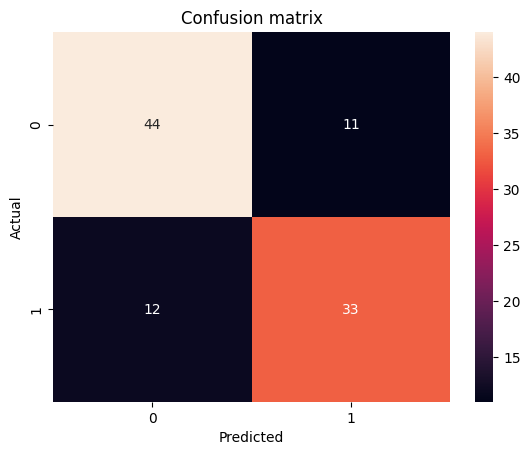

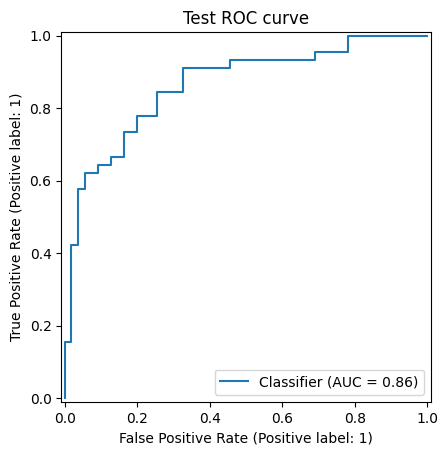

In [5]:
best_model = models["Logistic Regression"]
best_model.fit(X_train, y_train)

prob = best_model.predict_proba(X_test)[:,1]
pred = (prob >= .5).astype(int)

print("Test accuracy:", round(accuracy_score(y_test, pred),3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, prob),3))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, prob)
plt.title("Test ROC curve")
plt.show()

## 5. Interpret selected genomic features

In [6]:
selector = best_model.named_steps["select"]
selected_features = X.columns[selector.get_support()]

coef = best_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coef
}).sort_values("Coefficient", key=np.abs, ascending=False)

display(coef_df.head(20))

,Feature,Coefficient
34,Feature_168,1.228710
3,Feature_020,-1.160732
8,Feature_041,-1.119540
6,Feature_026,-0.688338
14,Feature_057,0.670138
28,Feature_156,-0.666412
31,Feature_163,-0.653839
26,Feature_125,-0.584939
12,Feature_052,0.535127
20,Feature_085,-0.532715


## 6. Optional: genome-style annotation table

In a real project, these feature IDs would be mapped to genes/variants using appropriate annotation resources.

In [7]:
annotation = pd.DataFrame({
    "Feature": features,
    "Chromosome": np.random.choice([f"chr{i}" for i in range(1,23)], len(features)),
    "Position": np.random.randint(1_000_000, 150_000_000, len(features))
})

interpretable = coef_df.merge(annotation, on="Feature", how="left")
display(interpretable.head(15))

interpretable.to_csv("ml_genomics_feature_importance.csv", index=False)

,Feature,Coefficient,Chromosome,Position
0,Feature_168,1.228710,chr19,34232368
1,Feature_020,-1.160732,chr17,93539858
2,Feature_041,-1.119540,chr9,124601535
3,Feature_026,-0.688338,chr8,113173800
4,Feature_057,0.670138,chr14,139289062
5,Feature_156,-0.666412,chr8,11862035
6,Feature_163,-0.653839,chr4,146972610
7,Feature_125,-0.584939,chr7,57546778
8,Feature_052,0.535127,chr16,88344743
9,Feature_085,-0.532715,chr22,33729614


## Student exercises

1. Compare k = 20, 40, 80 selected features.
2. Add an SVM model.
3. Compare ROC-AUC with PR-AUC for an imbalanced dataset.
4. Repeat the experiment with 10-fold cross-validation.
5. Explain why selecting features before cross-validation can inflate performance.
6. Design a genomic ML problem using TCGA mutation/expression data.
7. Add permutation importance and discuss model interpretability.

### Publication-oriented extension
Use nested cross-validation, external validation, calibration analysis, confidence intervals, and biological validation before claiming a predictive biomarker.